# Plasma deceleration analysis - 02/04/2026

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append(r'D:\CLARA\HALHF_at_CLARA\online_analysis')

from HALHF_CLARA_analysis.CLARA_dataset import CLARADataset
from HALHF_CLARA_analysis.utils.colors import FLASHForward as FF_cmap
from HALHF_CLARA_analysis.plotting import plot_grouped_waterfall



In [14]:
#%% set plot styles
import matplotlib as mpl

mpl.rcParams["figure.figsize"] = (12, 6)
mpl.rc("xtick", labelsize=16)
mpl.rc("ytick", labelsize=16)
mpl.rc("font", size=18)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=["navy", "orange", "mediumseagreen", "dodgerblue", "blueviolet", "gold"]
)

norm = lambda x , xa : (x-np.min(xa))/(np.max(xa)-np.min(xa))

## Background data

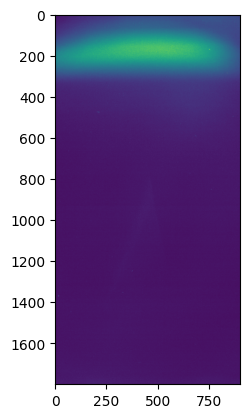

In [2]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_185150.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')
data = dset.load_data(['CLA-FED-DIA-CAM-02'])
bg_image = data['CLA-FED-DIA-CAM-02'].iloc[0]

plt.figure()
plt.imshow(bg_image)

## Uncompressed beam
* Primarily a lensing effect seen

(<Figure size 2400x800 with 2 Axes>,
 <Axes: xlabel='Discharge Timing [$\\mu$s]', ylabel='x'>)

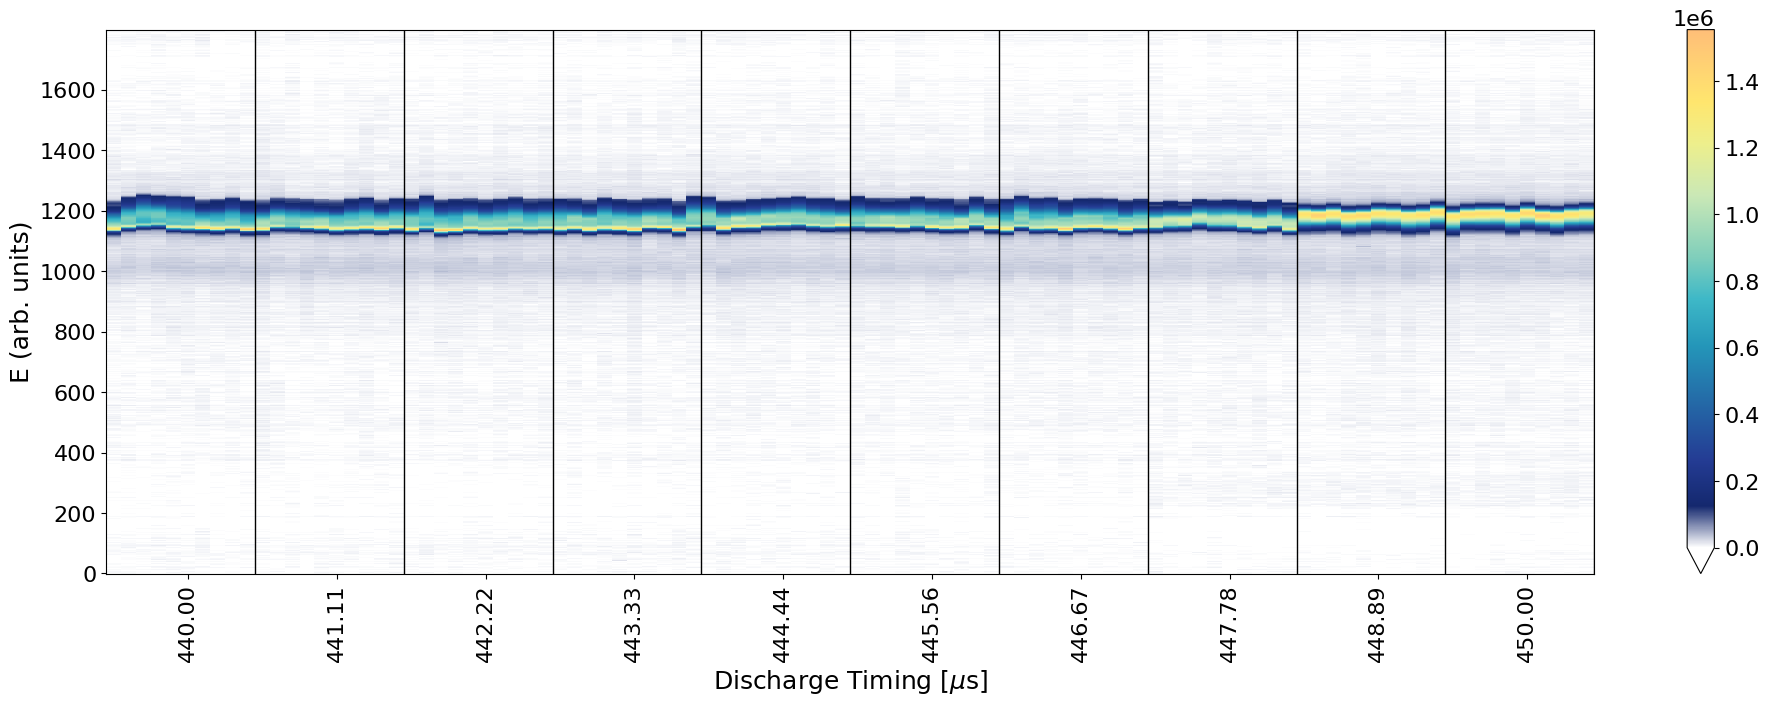

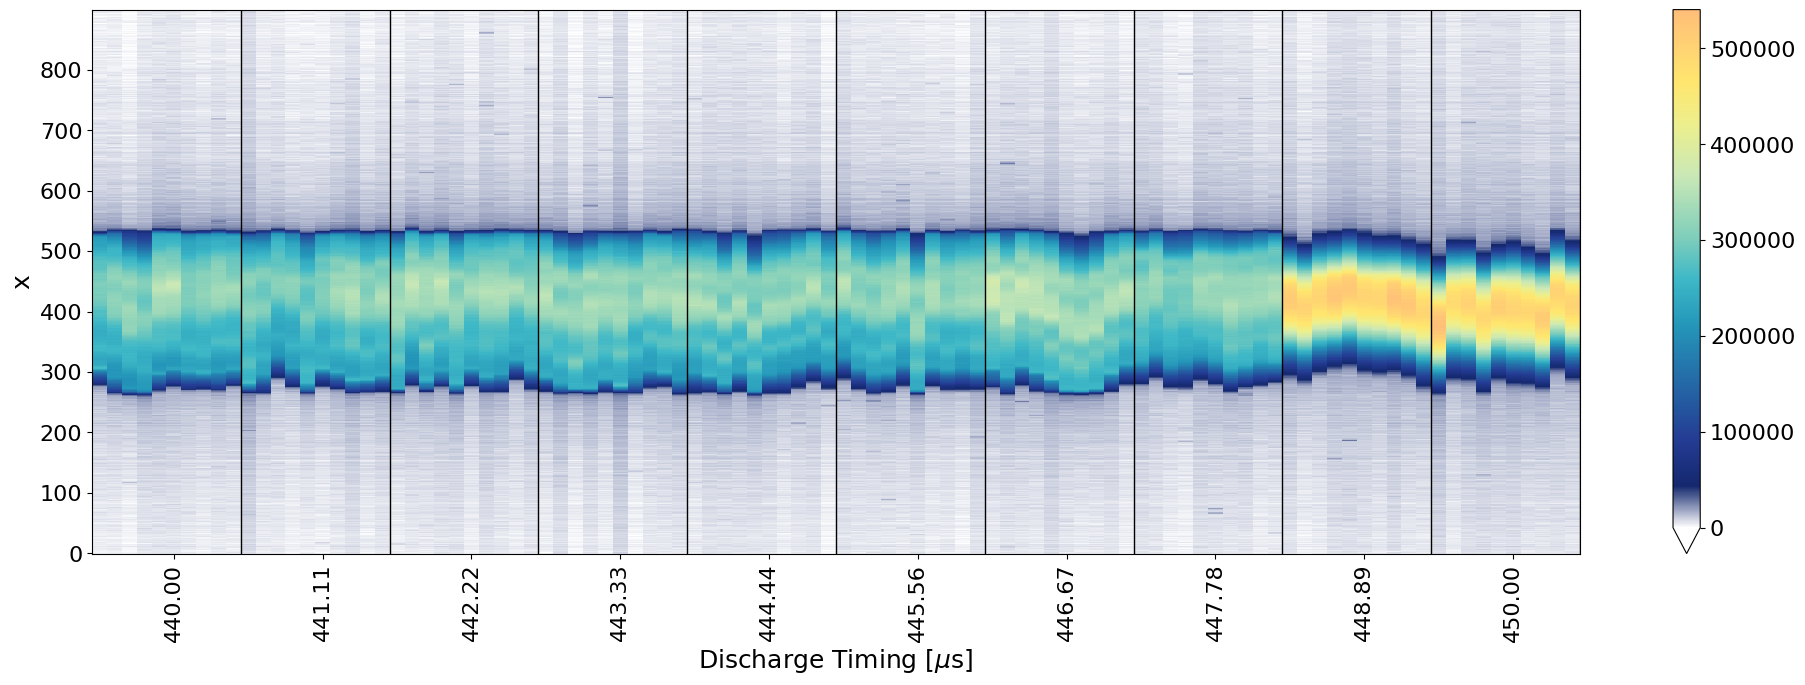

In [15]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_182435.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [np.subtract(im.astype(int) , bg_image.astype(int)) for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

plot_grouped_waterfall(data.yprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)
plt.ylabel('E (arb. units)')

plot_grouped_waterfall(data.xprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)

## First deceleration

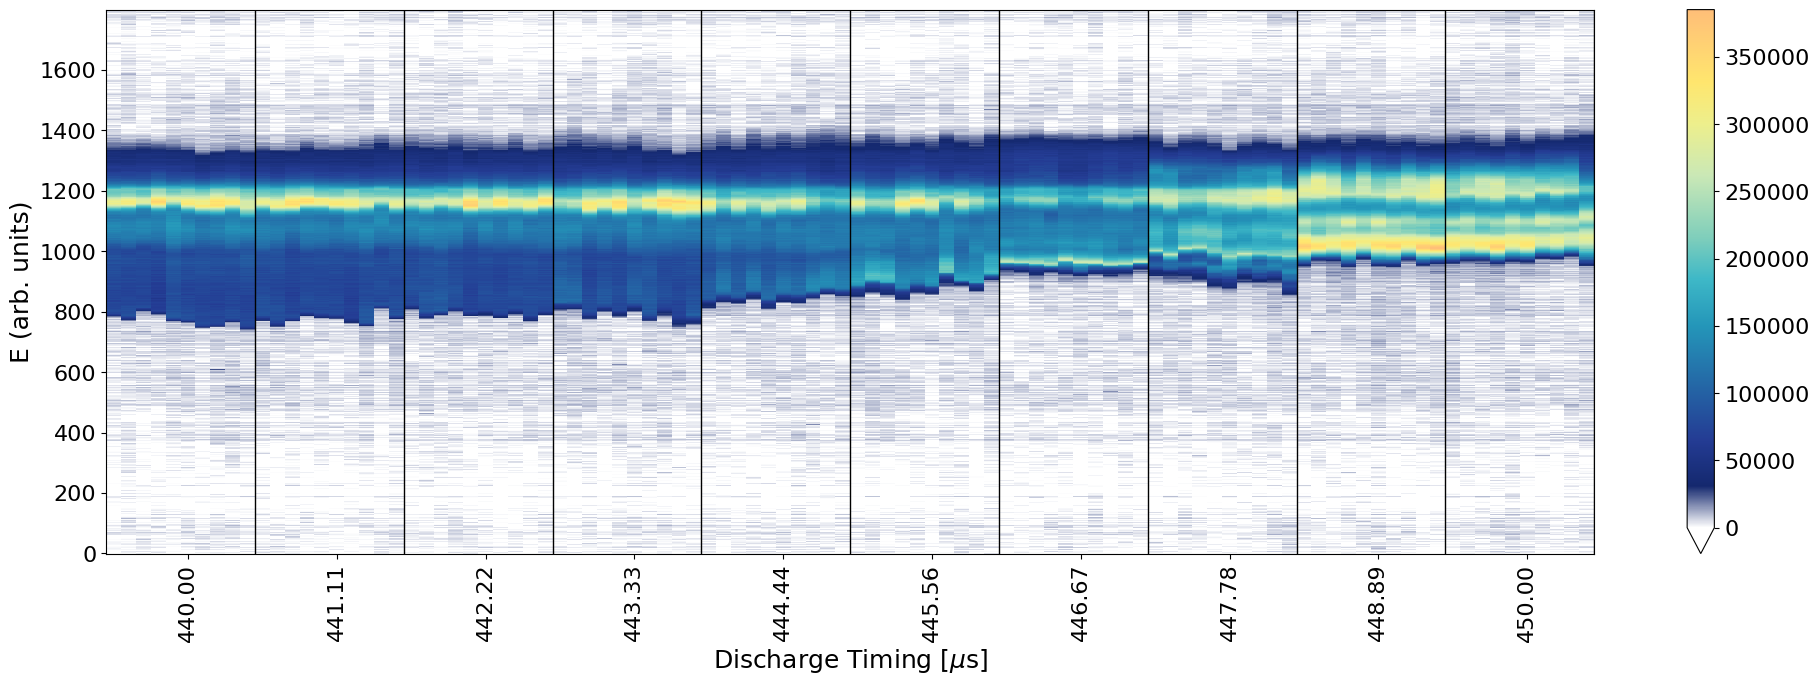

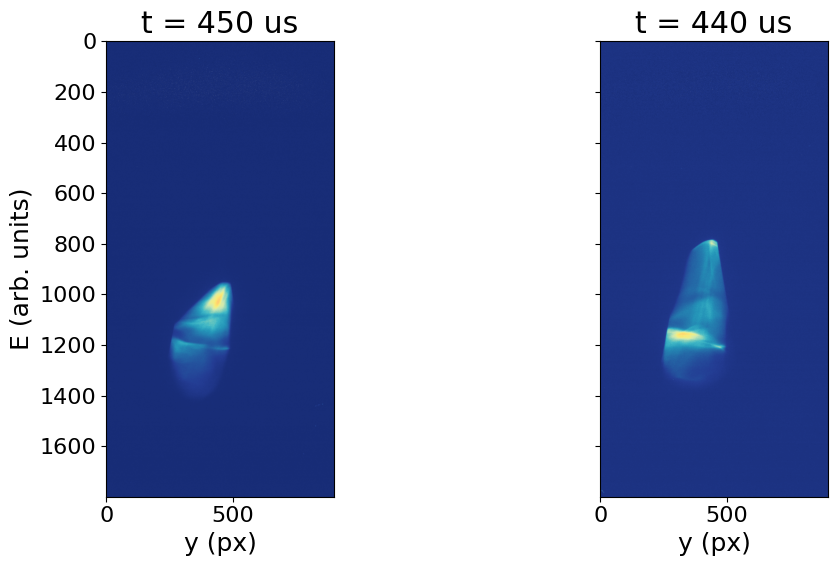

In [23]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_183411.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [np.subtract(im.astype(int) , bg_image.astype(int)) for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

plot_grouped_waterfall(data.yprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)
plt.ylabel('E (arb. units)')

fig , axs = plt.subplots(ncols = 2 , sharey = True)

axs[0].imshow(data.ESPEC.iloc[-1] , cmap = FF_cmap)
axs[0].set_title(f't = 450 us')
axs[0].set_ylabel('E (arb. units)')
axs[0].set_xlabel('y (px)')

axs[-1].imshow(data.ESPEC.iloc[0], cmap = FF_cmap)
axs[-1].set_title(f't = 440 us')
axs[-1].set_xlabel('y (px)')

fig.tight_layout()


## Plasma deceleration, increased compression

Text(0, 0.5, 'E (arb. units)')

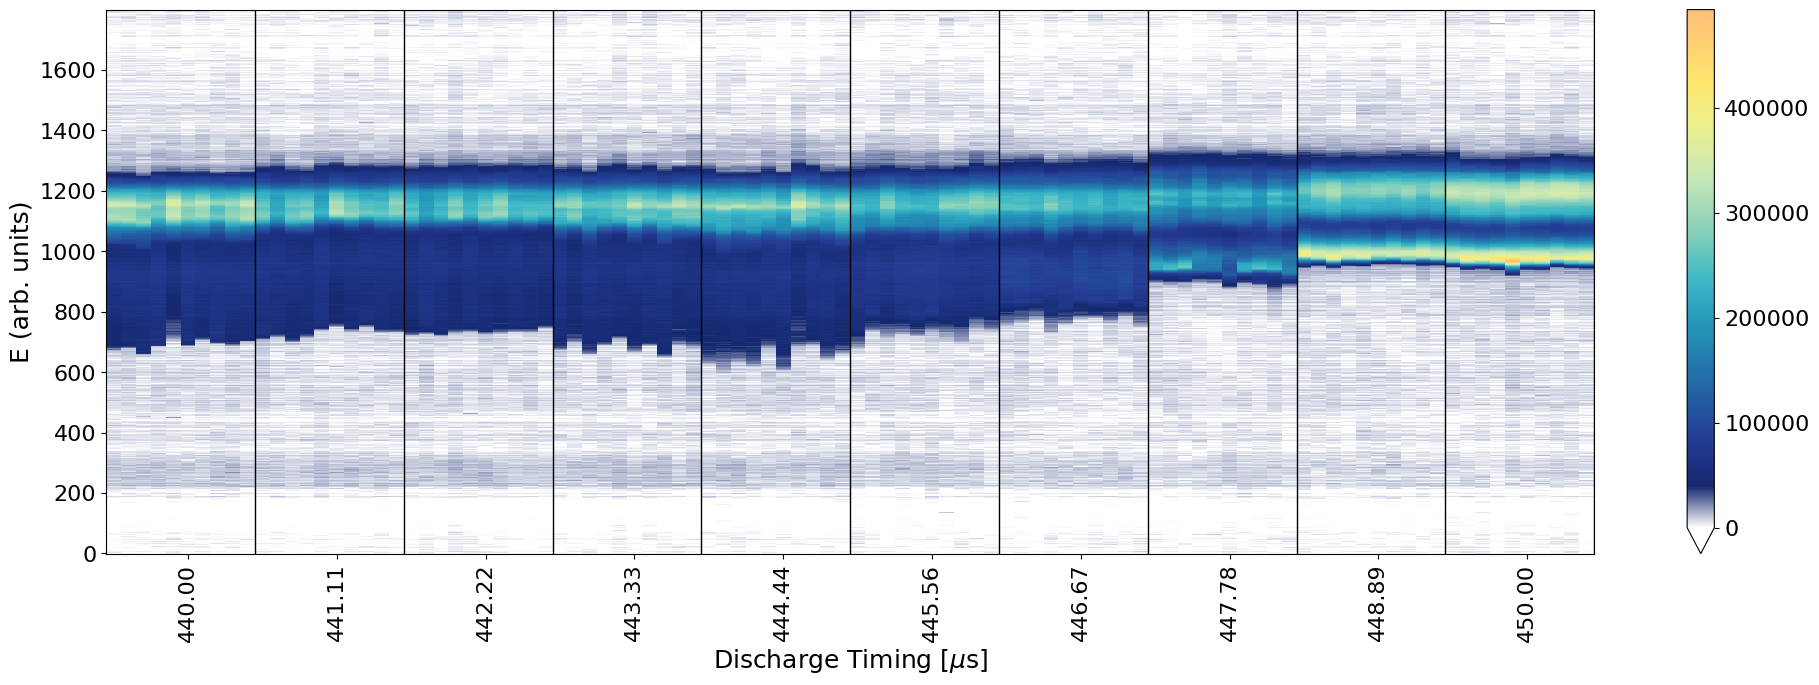

In [20]:
dset_path = r'\\fed.cclrc.ac.uk\Org\NLab\ASTeC\Projects\VELA\Work\2026\04\02\MultiSourceDAQ_20260402_184810.hdf'
dset = CLARADataset(dset_path , image_dir = r'\\claraserv3.dl.ac.uk\CameraImages\2026\4\2\\')

data = dset.load_data(['CLA-FED-DIA-CAM-02'])
data['ESPEC'] = [np.subtract(im.astype(int) , bg_image.astype(int)) for im in data['CLA-FED-DIA-CAM-02']]
data['xprof'] = [im.sum(axis=0) for im in data.ESPEC]
data['yprof'] = [im.sum(axis=1) for im in data.ESPEC]

fig , ax = plot_grouped_waterfall(data.yprof , data['CLA-C68-TIM-EVR-05:Pul3-Delay-SP'] ,
                        group_label='Discharge Timing' , group_units='$\mu$s' ,
                        cmap = FF_cmap , vmin = 0)
plt.ylabel('E (arb. units)')